[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ofermend/hands-on-rag/blob/main/chapter2/embedding.ipynb)

# Chapter 2: Sentence Embeddings and Similarity

This notebook demonstrates how to generate sentence embeddings using SentenceTransformers and compute cosine similarity between sentences.

**What you'll learn:**
- Generate sentence embeddings using the all-MiniLM-L6-v2 model
- Compute and visualize cosine similarity matrices
- Understand how semantic meaning is captured in embedding dimensions

**Prerequisites:** `pip install sentence-transformers matplotlib`
JSON:    bits ─► decimal math ─► "0.10000000149011612" ─► decimal math ─► bits
Base64:  bits ─► regroup      ─► "zczMPQ=="            ─► regroup      ─► bits

## Generate Embeddings

We use the all-MiniLM-L6-v2 model (via the SentenceTransformer library) to convert short sentences into 384-dimensional vectors that capture their semantic meaning.

In [2]:
import random
from typing import Final

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import torch
from sentence_transformers import SentenceTransformer, SimilarityFunction

EMBEDDING_MODEL_NAME: Final = "all-MiniLM-L6-v2"

# The first run downloads the model from the Hugging Face Hub; later runs load it from the local cache.
# Cosine similarity is set explicitly so the scores below do not depend on the model's stored default.
embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME,
    similarity_fn_name=SimilarityFunction.COSINE,
)

In [3]:
print(embedding_model)

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)


In [5]:
sentences: list[str] = [
    "I am a happy person.",
    "I am a joyful person.",
    "I am a pessimistic person.",
    "I am not an optimistic person.",
]

# One row per sentence, one column per embedding dimension.
embeddings: npt.NDArray[np.float32] = embedding_model.encode(
    sentences,
    convert_to_numpy=True,
    convert_to_tensor=False,
)

In [10]:
PREVIEW_DIMENSION_COUNT: Final = 5

print(embeddings.shape)

# Print only the first few dimensions because all 384 do not fit on screen.
embeddings_preview = embeddings[:, :PREVIEW_DIMENSION_COUNT]
print(embeddings_preview)

(4, 384)
[[ 0.00464717  0.0665106   0.01479137 -0.02955693 -0.03556165]
 [ 0.03454592  0.05649187  0.00730666 -0.07299504 -0.06663916]
 [ 0.06152029  0.05317358  0.0178834   0.03482828 -0.03031247]
 [ 0.02471697  0.02527612 -0.00175563  0.02087231 -0.03713484]]


## Cosine Similarity

By computing pairwise cosine similarity we can see how closely the model considers each sentence pair — near-synonyms should score high, opposites should score low.

In [11]:
# Entry [row, column] is the cosine similarity between sentence `row` and sentence `column`.
similarity_matrix: torch.Tensor = embedding_model.similarity(embeddings, embeddings)
print(similarity_matrix)

tensor([[1.0000, 0.8151, 0.3864, 0.5210],
        [0.8151, 1.0000, 0.3383, 0.4128],
        [0.3864, 0.3383, 1.0000, 0.7047],
        [0.5210, 0.4128, 0.7047, 1.0000]])


> **Note:** The similarity scores confirm that embeddings capture semantic meaning. "Happy" and "joyful" score 0.82 (near-synonyms), while "happy" and "pessimistic" score only 0.39 (opposite sentiment). Notice that "not optimistic" scores 0.70 with "pessimistic" — the model partially understands negation but doesn't treat it as a perfect synonym.

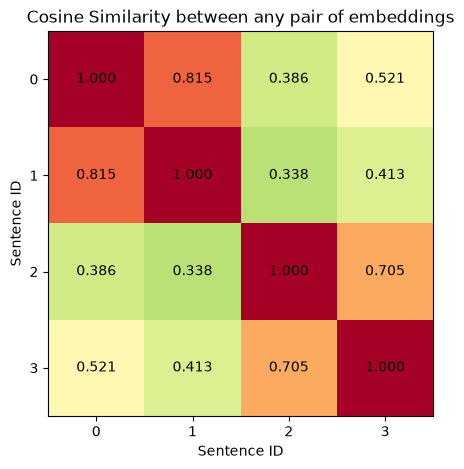

In [12]:
sentence_count = len(sentences)
sentence_ids = list(range(sentence_count))
similarity_values: npt.NDArray[np.float32] = similarity_matrix.numpy()

plt.figure(figsize=(5, 5))
plt.imshow(
    similarity_values,
    cmap="RdYlGn_r",
    interpolation="nearest",
    vmin=0,
    vmax=1,
)
plt.title("Cosine Similarity between any pair of embeddings")
plt.xlabel("Sentence ID")
plt.ylabel("Sentence ID")
plt.xticks(sentence_ids)
plt.yticks(sentence_ids)

# Write each score on its heatmap cell. imshow puts matrix rows on the y axis, so x is the column index.
for row_index in range(sentence_count):
    for column_index in range(sentence_count):
        similarity_score = float(similarity_values[row_index, column_index])
        similarity_label = f"{similarity_score:.3f}"
        plt.text(
            x=column_index,
            y=row_index,
            s=similarity_label,
            ha="center",
            va="center",
            color="black",
        )

plt.show()

## Similarity on Random Dimensions

To show that semantic information is spread across the full embedding vector rather than concentrated in a few dimensions, we compute similarity using only a random slice of the 384 dimensions.

In [13]:
embedding_dimension_count: int = embeddings.shape[1]

# randint includes both ends, so each boundary is a valid slice index from 0 to the dimension count.
# Not used for security, so the non-cryptographic generator is fine.
first_boundary = random.randint(0, embedding_dimension_count)  # noqa: S311  # demo sampling, not security
second_boundary = random.randint(0, embedding_dimension_count)  # noqa: S311  # demo sampling, not security

if first_boundary <= second_boundary:
    slice_start = first_boundary
    slice_end = second_boundary
else:
    slice_start = second_boundary
    slice_end = first_boundary

print(f"Using semantic dimensions {slice_start} to {slice_end}")

embedding_slice = embeddings[:, slice_start:slice_end]
slice_similarity_matrix: torch.Tensor = embedding_model.similarity(embedding_slice, embedding_slice)
print(slice_similarity_matrix)

Using semantic dimensions 285 to 353
tensor([[1.0000, 0.7988, 0.3174, 0.4090],
        [0.7988, 1.0000, 0.2002, 0.2499],
        [0.3174, 0.2002, 1.0000, 0.7319],
        [0.4090, 0.2499, 0.7319, 1.0000]])
